First 5 Rows:
   sepal.length  sepal.width  petal.length  petal.width variety
0           5.1          3.5           1.4          0.2  Setosa
1           4.9          3.0           1.4          0.2  Setosa
2           4.7          3.2           1.3          0.2  Setosa
3           4.6          3.1           1.5          0.2  Setosa
4           5.0          3.6           1.4          0.2  Setosa

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal.length  150 non-null    float64
 1   sepal.width   150 non-null    float64
 2   petal.length  150 non-null    float64
 3   petal.width   150 non-null    float64
 4   variety       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB
None

Missing Values:
sepal.length    0
sepal.width     0
petal.length    0
petal.width     0
variety         0
dtype: int64

Outl

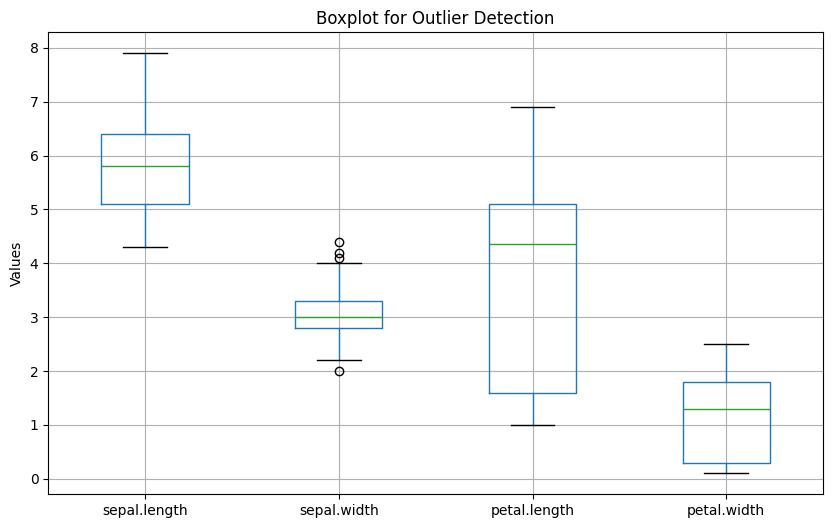


Handling Outliers Using IQR Capping

Outliers handled successfully.

Confusion Matrix:
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]

Class-wise TP, FP, TN, FN

Class 0
TP = 10
FP = 0
TN = 20
FN = 0

Class 1
TP = 9
FP = 0
TN = 21
FN = 0

Class 2
TP = 11
FP = 0
TN = 19
FN = 0

Accuracy: 1.0
Error Rate: 0.0
Precision: 1.0
Recall: 1.0


In [2]:
# Data Analytics III
# Naive Bayes Classification on Iris Dataset
# Including Proper Outlier Detection & Handling

# Step 1: Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score
)

# Step 2: Load Dataset
df = pd.read_csv("iris.csv")

# Step 3: Display First 5 Rows
print("First 5 Rows:")
print(df.head())

# Step 4: Dataset Information
print("\nDataset Info:")
print(df.info())

# Step 5: Check Missing Values
print("\nMissing Values:")
print(df.isnull().sum())

# ---------------------------------------------------
# STEP 6: OUTLIER DETECTION
# ---------------------------------------------------

# Numerical columns only
numerical_cols = [
    'sepal.length',
    'sepal.width',
    'petal.length',
    'petal.width'
]

print("\nOutlier Detection Using IQR Method")

for col in numerical_cols:

    # Calculate Q1 and Q3
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    # Interquartile Range
    IQR = Q3 - Q1

    # Lower and Upper Limits
    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    # Find Outliers
    outliers = df[
        (df[col] < lower_limit) |
        (df[col] > upper_limit)
    ]

    print(f"\nColumn: {col}")
    print("Number of Outliers:", len(outliers))

# ---------------------------------------------------
# STEP 7: VISUALIZE OUTLIERS
# ---------------------------------------------------

plt.figure(figsize=(10, 6))
df.boxplot(column=numerical_cols)

plt.title("Boxplot for Outlier Detection")
plt.ylabel("Values")
plt.show()

# ---------------------------------------------------
# STEP 8: HANDLE OUTLIERS
# ---------------------------------------------------

# Since iris dataset is a clean benchmark dataset,
# we use capping instead of removing rows.
# This prevents unnecessary data loss.

print("\nHandling Outliers Using IQR Capping")

for col in numerical_cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    # Capping lower outliers
    df[col] = np.where(
        df[col] < lower_limit,
        lower_limit,
        df[col]
    )

    # Capping upper outliers
    df[col] = np.where(
        df[col] > upper_limit,
        upper_limit,
        df[col]
    )

print("\nOutliers handled successfully.")

# ---------------------------------------------------
# STEP 9: SEPARATE FEATURES AND TARGET
# ---------------------------------------------------

X = df.drop("variety", axis=1)
y = df["variety"]

# ---------------------------------------------------
# STEP 10: ENCODE TARGET COLUMN
# ---------------------------------------------------

# Only target column is encoded because
# feature columns are already numerical.

le = LabelEncoder()
y = le.fit_transform(y)

# ---------------------------------------------------
# STEP 11: TRAIN-TEST SPLIT
# ---------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# ---------------------------------------------------
# STEP 12: CREATE MODEL
# ---------------------------------------------------

# GaussianNB is suitable because
# all feature columns are continuous numerical values.

model = GaussianNB()

# ---------------------------------------------------
# STEP 13: TRAIN MODEL
# ---------------------------------------------------

model.fit(X_train, y_train)

# ---------------------------------------------------
# STEP 14: PREDICTION
# ---------------------------------------------------

y_pred = model.predict(X_test)

# ---------------------------------------------------
# STEP 15: CONFUSION MATRIX
# ---------------------------------------------------

cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
print(cm)

# ---------------------------------------------------
# STEP 16: TP, FP, TN, FN
# ---------------------------------------------------

print("\nClass-wise TP, FP, TN, FN")

for i in range(len(cm)):

    TP = cm[i, i]

    FP = cm[:, i].sum() - TP

    FN = cm[i, :].sum() - TP

    TN = cm.sum() - (TP + FP + FN)

    print(f"\nClass {i}")
    print("TP =", TP)
    print("FP =", FP)
    print("TN =", TN)
    print("FN =", FN)

# ---------------------------------------------------
# STEP 17: ACCURACY
# ---------------------------------------------------

accuracy = accuracy_score(y_test, y_pred)

print("\nAccuracy:", accuracy)

# ---------------------------------------------------
# STEP 18: ERROR RATE
# ---------------------------------------------------

error_rate = 1 - accuracy

print("Error Rate:", error_rate)

# ---------------------------------------------------
# STEP 19: PRECISION
# ---------------------------------------------------

precision = precision_score(
    y_test,
    y_pred,
    average='weighted'
)

print("Precision:", precision)

# ---------------------------------------------------
# STEP 20: RECALL
# ---------------------------------------------------

recall = recall_score(
    y_test,
    y_pred,
    average='weighted'
)

print("Recall:", recall)